# Lab 2 — ML Primitives in NumPy

Run this notebook top to bottom as you build out `knn.py`, `gradient_descent.py`, and `pca.py` in this same folder. Each section below is a placeholder — see `Lab2_Instructions.md` for what belongs in each cell.

This notebook is just a shell: it imports your functions and gives you a place to call them, but the data generation, plotting, and test calls are yours to write.

In [40]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import os
os.makedirs('plots', exist_ok=True)

from knn import knn_predict, predict_grid ,euclidean_distance, cosine_similarity
from gradient_descent import f, grad_f, gradient_descent_1d, f2, grad_f2, gradient_descent_2d
from pca import pca_via_svd

## Part A: k-NN Classifier

In [41]:
# generating a small 2-class training set (X_train, y_train)
np.random.seed(0)
class_a = np.random.randn(30, 2) + np.array([2, 2])
class_b = np.random.randn(30, 2) + np.array([-2, -2])
X_train = np.vstack([class_a, class_b])
y_train = np.array([0] * 30 + [1] * 30)


Query Point [ 0.5 -0.5] is classified as: Class 1


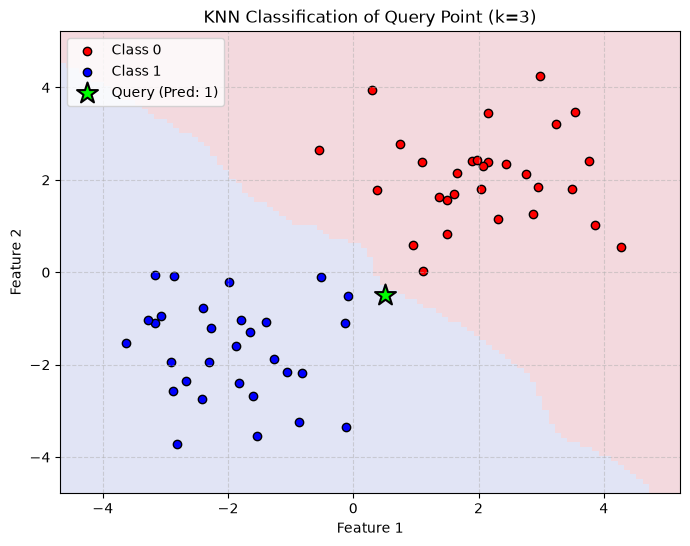

In [42]:
# TODO: pick a query point and call knn_predict to classify it

x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

step_size = 0.1 
xx, yy = np.meshgrid(np.arange(x_min, x_max, step_size),np.arange(y_min, y_max, step_size))

grid_preds = predict_grid(xx, yy, X_train, y_train, k=3)

query_point = np.array([0.5, -0.5])


predicted_class = knn_predict(query_point, X_train, y_train, k=3)
print(f"Query Point {query_point} is classified as: Class {predicted_class}")


plt.figure(figsize=(8, 6))


plt.pcolormesh(xx, yy, grid_preds, cmap='coolwarm_r', alpha=0.15, shading='auto')

plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='red', label='Class 0', edgecolors='k')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='blue', label='Class 1', edgecolors='k')


plt.scatter(query_point[0], query_point[1], c='lime', marker='*', s=250, label=f'Query (Pred: {predicted_class})', edgecolors='black', linewidths=1.5)

plt.title(f"KNN Classification of Query Point (k=3)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.grid(True, linestyle='--', alpha=0.5)


plt.legend(loc='upper left')

plt.savefig('plots/knn_query_classification.png', bbox_inches='tight', dpi=300)

plt.show()



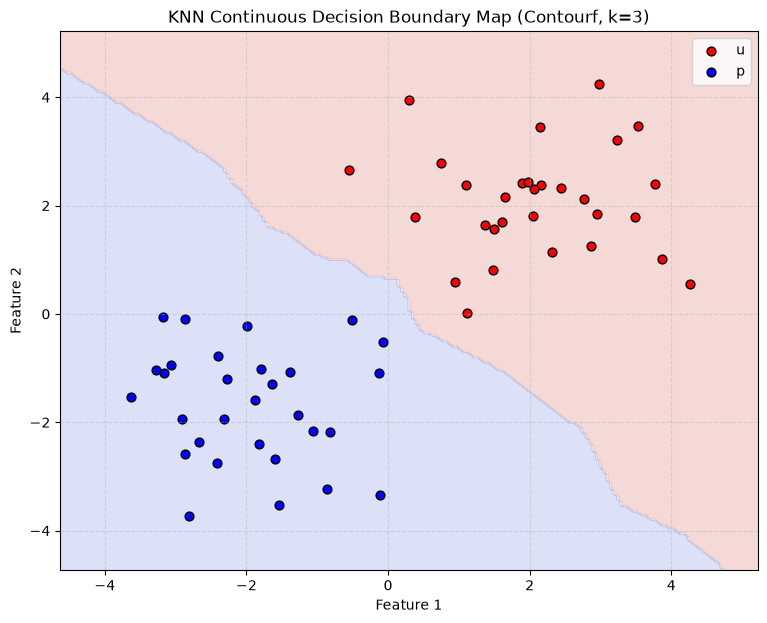

In [43]:
# TODO: build a meshgrid over the training data's range, classify every grid point,
# and plot the decision boundary with contourf (don't forget to reshape predictions to xx.shape)



margin = 1.0
x_min, x_max = X_train[:, 0].min() - margin, X_train[:, 0].max() + margin
y_min, y_max = X_train[:, 1].min() - margin, X_train[:, 1].max() + margin


step_size = 0.05  
xx, yy = np.meshgrid(np.arange(x_min, x_max, step_size),
                     np.arange(y_min, y_max, step_size))

grid_preds = predict_grid(xx, yy, X_train, y_train, k=3)


plt.figure(figsize=(9, 7))


plt.contourf(xx, yy, grid_preds, cmap='coolwarm_r', alpha=0.2)


plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='red', label='Class 0', edgecolors='k', s=40)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='blue', label='Class 1', edgecolors='k', s=40)


plt.title("KNN Continuous Decision Boundary Map (Contourf, k=3)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.grid(True, linestyle='--', alpha=0.4)


plt.legend("upper left")
plt.savefig('plots/knn_continuous_boundary.png', bbox_inches='tight', dpi=300)
plt.show()


## Part B: Gradient Descent

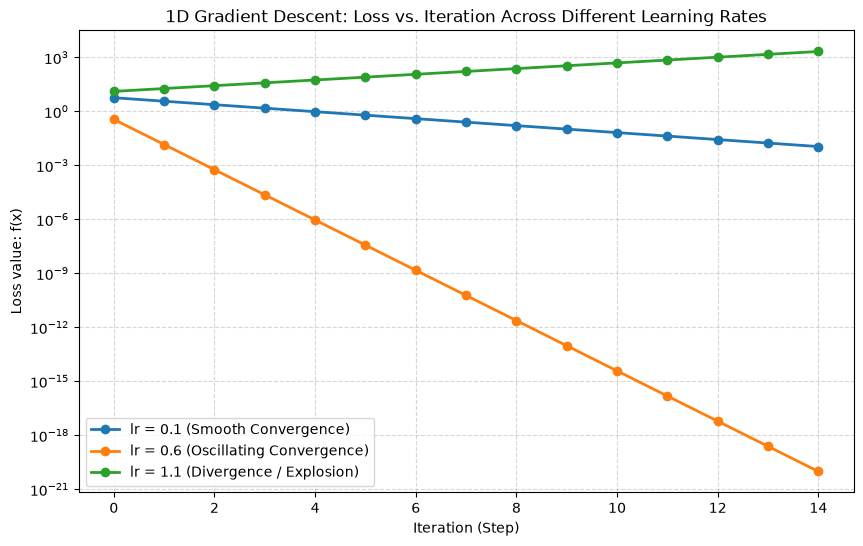

In [44]:
# TODO: run gradient_descent_1d with at least three learning rates and plot loss vs. iteration for each
# (include at least one learning rate that visibly diverges or oscillates)


start_point = 0.0
num_steps = 15
learning_rates = [0.1, 0.6, 1.1]

plt.figure(figsize=(10, 6))

#Iterate through each learning rate, run GD, compute loss, and plot
for lr in learning_rates:
    # Run your 1D gradient descent function
    final_x, history = gradient_descent_1d(start=start_point, lr=lr, steps=num_steps)
    
    # Calculate the loss f(x) = (x - 3)**2 at each step of the history
    losses = [f(x) for x in history]
    
    # Label behaviors clearly for the plot legend
    if lr == 0.1:
        label_text = f"lr = {lr} (Smooth Convergence)"
    elif lr == 0.6:
        label_text = f"lr = {lr} (Oscillating Convergence)"
    elif lr == 1.1:
        label_text = f"lr = {lr} (Divergence / Explosion)"
        
    # Plot loss vs iteration
    plt.plot(losses, marker='o', label=label_text, linewidth=2)


plt.title("1D Gradient Descent: Loss vs. Iteration Across Different Learning Rates")
plt.xlabel("Iteration (Step)")
plt.ylabel("Loss value: f(x)")
plt.yscale("log")  # Using log scale helps visualize converging and exploding curves simultaneously

plt.grid(True, linestyle='--', alpha=0.5, which="both")


plt.legend()
plt.savefig('plots/gd_1d_loss_comparison.png', bbox_inches='tight', dpi=300)

plt.show()





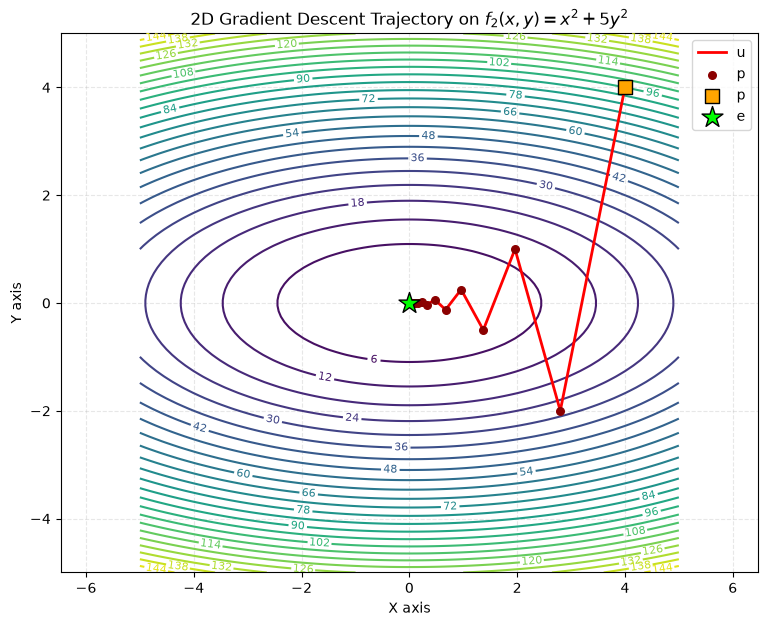

In [45]:
# TODO: run gradient_descent_2d and plot the path over a contour plot of f2


start_point = [4.0, 4.0]
lr = 0.15
steps = 20

final_point, path_history = gradient_descent_2d(start=start_point, lr=lr, steps=steps)


x_vals = np.linspace(-5, 5, 100)
y_vals = np.linspace(-5, 5, 100)
X_grid, Y_grid = np.meshgrid(x_vals, y_vals)


Z_grid = X_grid**2 + 5 * Y_grid**2


plt.figure(figsize=(9, 7))


contours = plt.contour(X_grid, Y_grid, Z_grid, levels=25, cmap='viridis')
plt.clabel(contours, inline=True, fontsize=8, fmt='%1.0f') # Adds value labels to lines

path_x = path_history[:, 0]
path_y = path_history[:, 1]


plt.plot(path_x, path_y, color='red', linestyle='-', linewidth=2, label='GD Optimization Path')
plt.scatter(path_x, path_y, color='darkred', marker='o', s=30, zorder=3)


plt.scatter(start_point[0], start_point[1], color='orange', marker='s', s=100, label='Start Point', zorder=4, edgecolors='k')
plt.scatter(0, 0, color='lime', marker='*', s=250, label='Minimum (0,0)', zorder=4, edgecolors='k')


plt.title("2D Gradient Descent Trajectory on $f_2(x, y) = x^2 + 5y^2$")
plt.xlabel("X axis")
plt.ylabel("Y axis")

plt.grid(True, linestyle='--', alpha=0.3)
plt.axis('equal') 

plt.legend("upper-right")
plt.savefig('plots/gd_2d_trajectory.png', bbox_inches='tight', dpi=300)
plt.show()


## Part C: PCA Via SVD

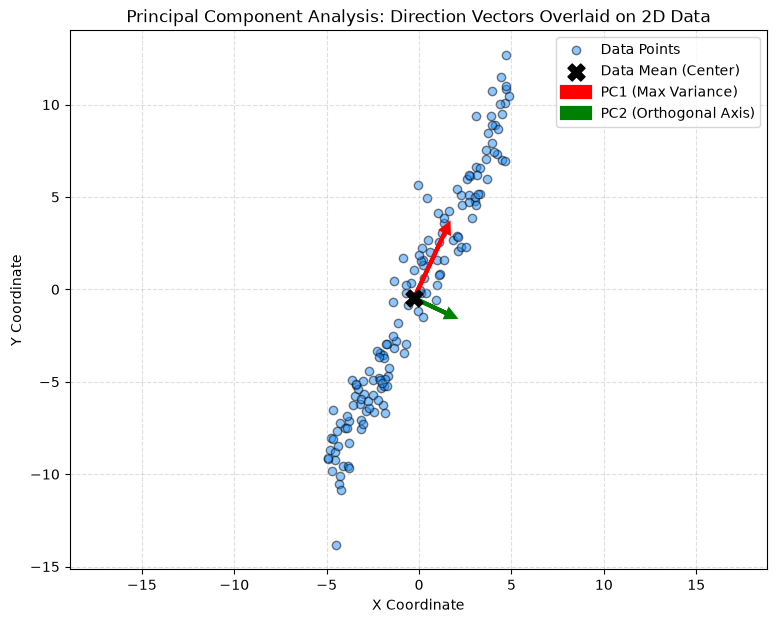

In [46]:
# TODO: generate a 2D dataset with an obvious principal direction (e.g. y = 2x + noise)

np.random.seed(42)
n_samples = 150


x = np.random.uniform(-5, 5, n_samples)
noise = np.random.normal(0, 1.5, n_samples)
y = 2 * x + noise


X_linear_data = np.vstack([x, y]).T


# Centering the data
mean = np.mean(X_linear_data, axis=0)
centered = X_linear_data - mean

# Performing SVD
U, S, Vt = np.linalg.svd(centered)

# Extract both principal components (n_components = 2)
components = Vt[:2]

plt.figure(figsize=(9, 7))

# Plot the raw dataset points
plt.scatter(
    X_linear_data[:, 0],
    X_linear_data[:, 1],
    color="dodgerblue",
    alpha=0.5,
    edgecolors="k",
    label="Data Points",
)

# Mark the dataset centroid center (mean)
plt.scatter(
    mean[0],
    mean[1],
    color="black",
    marker="X",
    s=150,
    zorder=5,
    label="Data Mean (Center)",
)

# Draw Principal Component 1 (Major Axis - Highest Variance Direction)
pc1 = components[0]
plt.arrow(
    mean[0],
    mean[1],
    pc1[0] * 4,
    pc1[1] * 4,
    head_width=0.4,
    head_length=0.4,
    fc="red",
    ec="red",
    linewidth=3,
    zorder=4,
    label="PC1 (Max Variance)",
)

# Draw Principal Component 2 (Minor Axis - Orthogonal Noise Direction)
pc2 = components[1]
plt.arrow(
    mean[0],
    mean[1],
    pc2[0] * 2,
    pc2[1] * 2,
    head_width=0.4,
    head_length=0.4,
    fc="green",
    ec="green",
    linewidth=3,
    zorder=4,
    label="PC2 (Orthogonal Axis)",
)

# final chart 
plt.title("Principal Component Analysis: Direction Vectors Overlaid on 2D Data")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.grid(True, linestyle="--", alpha=0.4)
plt.axis("equal")  

plt.legend()
plt.savefig('plots/pca_component_arrows.png', bbox_inches='tight', dpi=300)
plt.show()

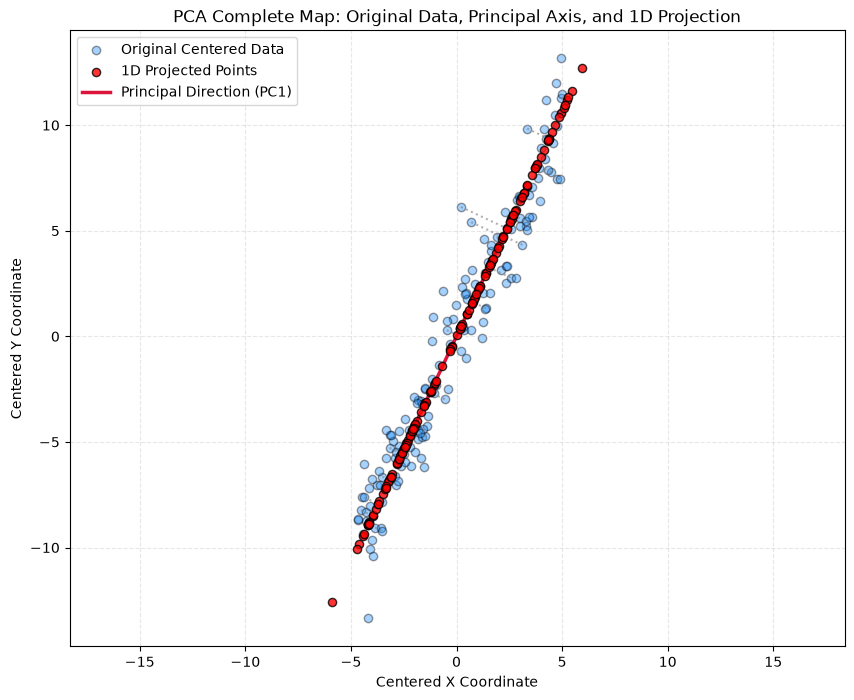

In [47]:
# TODO: call pca_via_svd, then plot the original (centered) data, the principal direction,
# and the projection together on one chart

mean_vals = np.mean(X_linear_data, axis=0)
X_centered = X_linear_data - mean_vals


X_projected, components, _ = pca_via_svd(X_linear_data, n_components=1)


pc1 = components[0]
X_reconstructed = X_projected @ pc1.reshape(1, -1)


plt.figure(figsize=(10, 8))


plt.scatter(X_centered[:, 0], X_centered[:, 1], color='dodgerblue', alpha=0.4, 
            edgecolors='k', label='Original Centered Data')


plt.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], color='red', alpha=0.8, 
            edgecolors='black', s=35, zorder=4, label='1D Projected Points')


for i in range(0, len(X_centered), 5):
    plt.plot([X_centered[i, 0], X_reconstructed[i, 0]], 
             [X_centered[i, 1], X_reconstructed[i, 1]], 
             color='gray', linestyle=':', alpha=0.6)


line_scale = 6
plt.plot([-pc1[0]*line_scale, pc1[0]*line_scale], [-pc1[1]*line_scale, pc1[1]*line_scale], 
         color='crimson', linestyle='-', linewidth=2.5, zorder=3, label='Principal Direction (PC1)')


plt.title("PCA Complete Map: Original Data, Principal Axis, and 1D Projection")
plt.xlabel("Centered X Coordinate")
plt.ylabel("Centered Y Coordinate")
plt.grid(True, linestyle='--', alpha=0.3)
plt.axis('equal')
plt.legend(loc='upper left')
plt.savefig('plots/pca_projection_complete_map.png', bbox_inches='tight', dpi=300)
plt.show()
